In [7]:
import pandas as pd
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
import pandas as pd
import numpy as np
import time
import asyncio
import httpx
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import time
import matplotlib.pyplot as plt
import seaborn as sns
pd.options.display.max_columns = None
from scipy import stats
import numpy as np


In [ ]:
df = pd.read_csv("comprehensive_apartment_sales.csv") 
print(df.head())
print(df.shape)

if 'dato_x' in df.columns:
    df['dato'] = df['dato_x']
    df.drop(columns=['dato_x'], inplace=True)


if all(col in df.columns for col in ['samlet_koebesum', 'kontant_koebesum', 'købesum']):
    
    for col in ['købesum', 'samlet_koebesum', 'kontant_koebesum']:
        low_count = (df[col] < 10000).sum()
        nan_count = df[col].isna().sum()
    
    problematic_kobesum = (df['købesum'] < 100000) | df['købesum'].isna()
    good_samlet = (df['samlet_koebesum'] >= 100000) & df['samlet_koebesum'].notna()
    
    samlet_fixes = problematic_kobesum & good_samlet
    df.loc[samlet_fixes, 'købesum'] = df.loc[samlet_fixes, 'samlet_koebesum']


    still_problematic = (df['købesum'] < 100000) | df['købesum'].isna()
    good_kontant = (df['kontant_koebesum'] >= 100000) & df['kontant_koebesum'].notna()

    kontant_fixes = still_problematic & good_kontant
    df.loc[kontant_fixes, 'købesum'] = df.loc[kontant_fixes, 'kontant_koebesum']
    
    
    
df.drop(columns=['samlet_koebesum', 'kontant_koebesum', 'loesoeresum', 'salgstype', 'status'], inplace=True)
print (len(df))



   bfe_nummer  kontant_koebesum  samlet_koebesum  loesoeresum  \
0      100000               NaN          4296181          NaN   
1      100030               NaN          2048000          NaN   
2      100030         2025000.0          2025000          NaN   
3      100030         2198000.0          2198000          NaN   
4      100031               NaN          2798000          NaN   

               salgstype                     dato_x    status  købesum  \
0  Almindelig fri handel  2018-12-02 23:00:00+00:00  gældende  4296181   
1  Almindelig fri handel  2018-10-14 22:00:00+00:00  gældende  2048000   
2  Almindelig fri handel  2019-09-12 22:00:00+00:00  gældende  2025000   
3  Almindelig fri handel  2020-09-29 22:00:00+00:00  gældende  2198000   
4  Almindelig fri handel  2018-09-30 22:00:00+00:00  gældende  2798000   

   sale_sequence  total_sales  is_most_recent  prev_købesum  price_change  \
0              1            1            True           NaN           NaN   
1         

In [11]:

lowest_prices = df.nsmallest(10, 'købesum')
print(lowest_prices[[ 'købesum', 'm2', 'bfe_nummer']])

                           købesum    m2  bfe_nummer
dato                                                
2002-07-31 22:00:00+00:00    25000  24.0      364159
2001-02-14 23:00:00+00:00    34500  31.0      272472
2000-09-30 22:00:00+00:00    35000  33.0      183911
2003-12-31 23:00:00+00:00    35000  28.0      400471
1999-06-30 22:00:00+00:00    38000  22.0      191100
1996-03-31 22:00:00+00:00    40000  30.0      406483
1996-10-31 23:00:00+00:00    40000  34.0      263999
2014-12-31 23:00:00+00:00    40000  31.0      406478
1995-03-31 22:00:00+00:00    43000  43.0      406926
1994-05-31 22:00:00+00:00    45000  34.0      263996


In [5]:
    
df = df.drop_duplicates(subset=['bfe_nummer', 'dato'], keep='first')
print (len(df))

485635


In [ ]:

df['dato'] = pd.to_datetime(df['dato'])

old_dates_mask = df['dato'] < '1992-01-01'
old_dates_data = df[old_dates_mask]

df = df[df['dato'] >= '1992-01-01']
print (len(df))


468278


In [ ]:

df['pris_pr_m2'] = df['købesum'] / df['m2']

suspicious_total = df['købesum'] < 25000 
suspicious_m2 = df['pris_pr_m2'] <  1000 

total_suspicious = suspicious_total | suspicious_m2
df = df[~total_suspicious].copy()

q1, q3 = np.percentile(df['købesum'], [25, 75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers_mask = (df['købesum'] < lower_bound) | (df['købesum'] > upper_bound)

df = df[~outliers_mask]

len(df)

439361

In [ ]:
#df['dato'] = pd.to_datetime(df['dato']) # im making date the index
df = df.sort_values('dato')
df = df.set_index('dato')

In [17]:
print(df.shape)

(420600, 26)


In [ ]:
#here i get the rolling mean for price per square meter for different time windows and geographical areas


df = df.sort_index()

levels = ['by', 'postnummer', 'område', 'region']
time_windows = ['30D', '180D', '365D']

for level in levels:
    for window in time_windows:
        new_col_name = f'pris_pr_m2_mean_{window}_{level}'
        
        #calculates rolling mean for price per square meter
        df[new_col_name] = df.groupby(level)['pris_pr_m2'].transform(
            lambda x: x.rolling(window, min_periods=1, closed='left', ).mean()
        ) #the first values will be nan, so we fill them with 0 we discard later
        print(f"Calculated {new_col_name}")



Calculated pris_pr_m2_mean_30D_by
Calculated pris_pr_m2_mean_180D_by
Calculated pris_pr_m2_mean_365D_by
Calculated pris_pr_m2_mean_30D_postnummer
Calculated pris_pr_m2_mean_180D_postnummer
Calculated pris_pr_m2_mean_365D_postnummer
Calculated pris_pr_m2_mean_30D_område
Calculated pris_pr_m2_mean_180D_område
Calculated pris_pr_m2_mean_365D_område
Calculated pris_pr_m2_mean_30D_region
Calculated pris_pr_m2_mean_180D_region
Calculated pris_pr_m2_mean_365D_region


In [22]:
df.tail(1000010)

,bfe_nummer,købesum,sale_sequence,total_sales,is_most_recent,prev_købesum,price_change,price_change_pct,prev_sale_date,years_since_last_sale,Købesum,Vær.,Byggeår,dato_y,stype,m2,btype,addresse,postnummer,by,område,region,full_address,x,y,pris_pr_m2_temp,pris_pr_m2,pris_pr_m2_prev,pris_pr_m2_mean_30D_by,pris_pr_m2_mean_180D_by,pris_pr_m2_mean_365D_by,pris_pr_m2_mean_30D_postnummer,pris_pr_m2_mean_180D_postnummer,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_30D_område,pris_pr_m2_mean_180D_område,pris_pr_m2_mean_365D_område,pris_pr_m2_mean_30D_region,pris_pr_m2_mean_180D_region,pris_pr_m2_mean_365D_region
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1992-01-01 23:00:00+00:00,406166,2115000,1,2,False,NaN,NaN,NaN,NaN,NaN,1750000,4,1941,12-07-2020,Alm. Salg,122.0,Ejerlejlighed,"Nørregade 4B, 2.",9850,Hirtshals,Nordjylland,Jylland,"Nørregade 4B, 2., 9850 Hirtshals",9.956707,57.590271,17336.065574,17336.065574,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1992-01-03 23:00:00+00:00,215716,640000,1,3,False,NaN,NaN,NaN,NaN,NaN,3050000,3,1938,27-02-2025,Andet,87.0,Ejerlejlighed,"I.H.Mundts Vej 19, 2. th",2830,Virum,"Hovedstaden, København",Sjælland,"I.H.Mundts Vej 19, 2. th, 2830 Virum",12.484174,55.780548,7356.321839,7356.321839,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1992-01-09 23:00:00+00:00,229609,288000,1,5,False,NaN,NaN,NaN,NaN,NaN,1250000,2,1966,15-08-2020,Alm. Salg,49.0,Ejerlejlighed,"Vejlegårdsparken 14, 2. 23",2665,Vallensbæk Strand,"Hovedstaden, København",Sjælland,"Vejlegårdsparken 14, 2. 23, 2665 Vallensbæk St...",12.384192,55.624578,5877.551020,5877.551020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7356.321839,7356.321839,7356.321839,7356.321839,7356.321839,7356.321839
1992-01-09 23:00:00+00:00,269328,429200,1,6,False,NaN,NaN,NaN,NaN,NaN,1850000,3,1967,05-02-2025,Alm. Salg,78.0,Ejerlejlighed,"Ejboparken 55, st. tv",4000,Roskilde,Andre øer,Sjælland,"Ejboparken 55, st. tv, 4000 Roskilde",12.065127,55.630015,5502.564103,5502.564103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7356.321839,7356.321839,7356.321839
1992-01-14 23:00:00+00:00,192632,565000,1,3,False,NaN,NaN,NaN,NaN,NaN,5295000,4,1939,27-02-2024,Alm. Salg,85.0,Ejerlejlighed,"Jyllandsvej 10, 2. mf",2000,Frederiksberg,"Hovedstaden, København",Sjælland,"Jyllandsvej 10, 2. mf, 2000 Frederiksberg",12.511232,55.678054,6647.058824,6647.058824,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6616.936430,6616.936430,6616.936430,6245.478987,6245.478987,6245.478987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-26 22:00:00+00:00,351077,1300000,3,3,True,1050000.0,250000.0,23.809524,2015-11-10 23:00:00+00:00,9.623546,1050000,2,1980,14-10-2015,Alm. Salg,70.0,Ejerlejlighed,"Brobjerg Parkvej 13, 2. 4",8250,Egå,Øst- og Midtjylland,Jylland,"Brobjerg Parkvej 13, 2. 4, 8250 Egå",10.265368,56.205662,18571.428571,18571.428571,15000.000000,25925.636324,25363.494030,24522.152741,25925.636324,25363.494030,24522.152741,32105.264108,30187.858330,29724.494566,27456.010892,25143.375799,24847.416910
2025-06-26 22:00:00+00:00,216900,3000000,5,5,True,2200000.0,800000.0,36.363636,2021-02-22 23:00:00+00:00,4.336756,2200000,3,1942,01-02-2021,Alm. Salg,56.0,Ejerlejlighed,"Christoffers Alle 88, st. tv",2800,Kongens Lyngby,"Hovedstaden, København",Sjælland,"Christoffers Alle 88, st. tv, 2800 Kongens Lyngby",12.485339,55.754573,53571.428571,53571.428571,39285.714286,44356.881950,39384.539078,38364.982465,44356.881950,39384.539078,38364.982465,46416.346983,44168.028325,43161.455348,41191.886405,39322.444797,38631.485300
2025-06-26 22:00:00+00:00,173633,3200000,5,5,True,1475000.0,1725000.0,116.949153,2014-07-24 22:00:00+00:00,10.924025,1475000,2,1900,09-07-2014,Alm. Salg,52.0,Ejerlejlighed,"Nordre Fasanvej 167, 3. tv",2000,Frederiksberg,"Hovedstaden, København",Sjælland,"Nordre Fasanvej 167, 3. tv, 2000 Frederiksberg",12.531909,55.692748,61538.461538,61538.461538,28365.384615,56357.020444,54306.878380,521

In [13]:
df.to_csv("afterlagtest.csv")

In [56]:
df = pd.read_csv("afterlagtest.csv")

In [57]:
df.head(10)


,dato,bfe_nummer,købesum,sale_sequence,total_sales,is_most_recent,prev_købesum,price_change,price_change_pct,prev_sale_date,years_since_last_sale,Købesum,Vær.,Byggeår,dato_y,stype,m2,btype,addresse,postnummer,by,område,region,full_address,x,y,pris_pr_m2_temp,pris_pr_m2,pris_pr_m2_prev,pris_pr_m2_mean_30D_by,pris_pr_m2_mean_180D_by,pris_pr_m2_mean_365D_by,pris_pr_m2_mean_30D_postnummer,pris_pr_m2_mean_180D_postnummer,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_30D_område,pris_pr_m2_mean_180D_område,pris_pr_m2_mean_365D_område,pris_pr_m2_mean_30D_region,pris_pr_m2_mean_180D_region,pris_pr_m2_mean_365D_region
0,1992-01-01 23:00:00+00:00,406166,2115000,1,2,False,NaN,NaN,NaN,NaN,NaN,1750000,4,1941,12-07-2020,Alm. Salg,122.0,Ejerlejlighed,"Nørregade 4B, 2.",9850,Hirtshals,Nordjylland,Jylland,"Nørregade 4B, 2., 9850 Hirtshals",9.956707,57.590271,17336.065574,17336.065574,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1992-01-01 23:00:00+00:00,206973,296270,1,4,False,NaN,NaN,NaN,NaN,NaN,2150000,3,1962,30-03-2008,Alm. Salg,101.0,Ejerlejlighed,"Lehwaldsvej 3, 5. d",2800,Kongens Lyngby,"Hovedstaden, København",Sjælland,"Lehwaldsvej 3, 5. d, 2800 Kongens Lyngby",12.500846,55.768293,2933.366337,2933.366337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1992-01-03 23:00:00+00:00,305838,210000,1,2,False,NaN,NaN,NaN,NaN,NaN,705000,2,1981,12-06-2020,Alm. Salg,74.0,Ejerlejlighed,"Slotsgade 7, st. th",6100,Haderslev,Sydjylland,Jylland,"Slotsgade 7, st. th, 6100 Haderslev",9.488972,55.250066,2837.837838,2837.837838,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17336.065574,17336.065574,17336.065574
3,1992-01-03 23:00:00+00:00,215716,640000,1,3,False,NaN,NaN,NaN,NaN,NaN,3050000,3,1938,27-02-2025,Andet,87.0,Ejerlejlighed,"I.H.Mundts Vej 19, 2. th",2830,Virum,"Hovedstaden, København",Sjælland,"I.H.Mundts Vej 19, 2. th, 2830 Virum",12.484174,55.780548,7356.321839,7356.321839,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2933.366337,2933.366337,2933.366337,2933.366337,2933.366337,2933.366337
4,1992-01-04 23:00:00+00:00,251512,325000,1,3,False,NaN,NaN,NaN,NaN,NaN,2160000,3,1972,26-09-2020,Alm. Salg,85.0,Ejerlejlighed,"Lyngborghave 50, 1. tv",3460,Birkerød,Nordsjælland,Sjælland,"Lyngborghave 50, 1. tv, 3460 Birkerød",12.415092,55.836981,3823.529412,3823.529412,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5144.844088,5144.844088,5144.844088
5,1992-01-09 23:00:00+00:00,269328,429200,1,6,False,NaN,NaN,NaN,NaN,NaN,1850000,3,1967,05-02-2025,Alm. Salg,78.0,Ejerlejlighed,"Ejboparken 55, st. tv",4000,Roskilde,Andre øer,Sjælland,"Ejboparken 55, st. tv, 4000 Roskilde",12.065127,55.630015,5502.564103,5502.564103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4704.405862,4704.405862,4704.405862
6,1992-01-09 23:00:00+00:00,229609,288000,1,5,False,NaN,NaN,NaN,NaN,NaN,1250000,2,1966,15-08-2020,Alm. Salg,49.0,Ejerlejlighed,"Vejlegårdsparken 14, 2. 23",2665,Vallensbæk Strand,"Hovedstaden, København",Sjælland,"Vejlegårdsparken 14, 2. 23, 2665 Vallensbæk St...",12.384192,55.624578,5877.551020,5877.551020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5144.844088,5144.844088,5144.844088,4704.405862,4704.405862,4704.405862
7,1992-01-14 23:00:00+00:00,273662,300000,1,5,False,NaN,NaN,NaN,NaN,NaN,900000,3,1964,05-05-2022,Alm. Salg,83.0,Ejerlejlighed,"Parkvej 24, 7. tv",4700,Næstved,Andre øer,Sjælland,"Parkvej 24, 7. tv, 4700 Næstved",11.756026,55.217545,3614.457831,3614.457831,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5502.564103,5502.564103,5502.564103,5098.666542,5098.666542,5098.666542
8,1992-01-14 23:00:00+00:00,318605,168300,1,6,False,NaN,NaN,NaN,NaN,NaN,862500,4,1955,25-08-2020,Alm. Salg,109.0,Ejerlejlighed,"Storegade 12, 1. th",6800,Varde,Sydjylland,Jylland,"Storegade 12, 1. th, 6800 Varde",8.483614,55.619677,1544.036697,1544.036697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2837.837838,2837.837838,2837.837838,10086.951706,10086.951706,10086.951706
9,1992-01-14 23:00:00+00:00,192632,565000,1,3,False,NaN,NaN,NaN,NaN,NaN,5295000,4,1939,27-02-2024,Alm. Salg,85.0,Ejerlejlighed,"Jyllandsvej 10, 2. mf",2000,Frederiksberg,"Hovedstaden, Køben

In [58]:
df['pris_pr_m2_prev'] = df['prev_købesum'] / df['m2']  

df['dato'] = pd.to_datetime(df['dato'], errors='coerce', utc=True)

df.sort_values(['bfe_nummer', 'dato'], inplace=True)

df['prev_sale_date'] = df.groupby('bfe_nummer')['dato'].shift(1)
df['prev_købesum'] = df.groupby('bfe_nummer')['købesum'].shift(1)
df['pris_pr_m2_prev'] = df.groupby('bfe_nummer')['pris_pr_m2'].shift(1)
df['pris_pr_m2_mean_postummer_prev'] = df.groupby('bfe_nummer')['pris_pr_m2_mean_365D_postnummer'].shift(1)
df['pris_pr_m2_mean_365D_by_prev'] = df.groupby('bfe_nummer')['pris_pr_m2_mean_365D_by'].shift(1)

df.set_index('dato', inplace=True)

df['days_since_last_sale'] = (df.index - df['prev_sale_date']).dt.days


In [59]:
df.head(10)

,bfe_nummer,købesum,sale_sequence,total_sales,is_most_recent,prev_købesum,price_change,price_change_pct,prev_sale_date,years_since_last_sale,Købesum,Vær.,Byggeår,dato_y,stype,m2,btype,addresse,postnummer,by,område,region,full_address,x,y,pris_pr_m2_temp,pris_pr_m2,pris_pr_m2_prev,pris_pr_m2_mean_30D_by,pris_pr_m2_mean_180D_by,pris_pr_m2_mean_365D_by,pris_pr_m2_mean_30D_postnummer,pris_pr_m2_mean_180D_postnummer,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_30D_område,pris_pr_m2_mean_180D_område,pris_pr_m2_mean_365D_område,pris_pr_m2_mean_30D_region,pris_pr_m2_mean_180D_region,pris_pr_m2_mean_365D_region,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_365D_by_prev,days_since_last_sale
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-12-02 23:00:00+00:00,100000,4296181,1,1,True,NaN,NaN,NaN,NaT,NaN,4296181,3,2019,11-12-2017,Alm. Salg,133.0,Ejerlejlighed,"Stadionvej 86, 3. 1",2600,Glostrup,"Hovedstaden, København",Sjælland,"Stadionvej 86, 3. 1, 2600 Glostrup",12.374093,55.667897,32302.112782,32302.112782,NaN,28562.422858,26461.939729,25434.196252,28562.422858,26461.939729,25434.196252,36088.301542,34966.830985,34493.509286,32972.455435,31952.834894,31551.749696,NaN,NaN,NaN
2018-10-14 22:00:00+00:00,100030,2048000,1,3,False,NaN,NaN,NaN,NaT,NaN,2198000,3,1929,28-07-2020,Alm. Salg,95.0,Ejerlejlighed,"Kronprinsensgade 55, st.",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 55, st., 6700 Esbjerg",8.446658,55.470418,21557.894737,21557.894737,NaN,17779.805432,17045.945373,17766.585423,17779.805432,17045.945373,17766.585423,14957.363891,14474.750297,14736.436189,21486.789671,21880.027114,22055.663780,NaN,NaN,NaN
2019-09-12 22:00:00+00:00,100030,2025000,2,3,False,2048000.0,-23000.0,-1.123047,2018-10-14 22:00:00+00:00,0.911704,2198000,3,1929,28-07-2020,Alm. Salg,95.0,Ejerlejlighed,"Kronprinsensgade 55, st.",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 55, st., 6700 Esbjerg",8.446658,55.470418,21315.789474,21315.789474,21557.894737,17866.325322,17615.640232,17460.604202,17866.325322,17615.640232,17460.604202,16078.608639,16408.236912,15874.301095,23522.688118,23859.629895,22778.456746,17766.585423,17766.585423,333.0
2020-09-29 22:00:00+00:00,100030,2198000,3,3,True,2025000.0,173000.0,8.543210,2019-09-12 22:00:00+00:00,1.048597,2198000,3,1929,28-07-2020,Alm. Salg,95.0,Ejerlejlighed,"Kronprinsensgade 55, st.",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 55, st., 6700 Esbjerg",8.446658,55.470418,23136.842105,23136.842105,21315.789474,18702.905040,17093.932735,17123.704883,18702.905040,17093.932735,17123.704883,16953.712985,16070.472866,15390.167131,23648.046235,22985.000398,22480.700392,17460.604202,17460.604202,383.0
2018-09-30 22:00:00+00:00,100031,2798000,1,2,False,NaN,NaN,NaN,NaT,NaN,2998000,4,1929,28-02-2019,Alm. Salg,133.0,Ejerlejlighed,"Kronprinsensgade 59, 1. th",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 59, 1. th, 6700 Esbjerg",8.446777,55.470578,21037.593985,21037.593985,NaN,17272.023346,17032.428974,17534.125740,17272.023346,17032.428974,17534.125740,14665.031372,14550.461378,14800.196460,22667.005074,21985.619463,22212.970611,NaN,NaN,NaN
2019-03-20 23:00:00+00:00,100031,2998000,2,2,True,2798000.0,200000.0,7.147963,2018-09-30 22:00:00+00:00,0.468172,2998000,4,1929,28-02-2019,Alm. Salg,133.0,Ejerlejlighed,"Kronprinsensgade 59, 1. th",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 59, 1. th, 6700 Esbjerg",8.446777,55.470578,22541.353383,22541.353383,21037.593985,17610.104413,17425.131419,17231.986035,17610.104413,17425.131419,17231.986035,14695.700856,15331.632227,15006.996356,19634.945505,21562.769030,21731.016994,17534.125740,17534.125740,171.0
2018-09-20 22:00:00+00:00,100032,2098000,1,1,True,NaN,NaN,NaN,NaT,NaN,2098000,3,1929,20-09-2018,Alm. Salg,95.0,Ejerlejlighed,"Kronprinsensgade 55, 1.",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 55, 1., 6700 Esbjerg",8.446658,55.470418,22084.210526,22084.210526,NaN,16884.291200,17135.272653,17484.471326,16884.291200,17135.272653,17484.471326,13819.185490,1453

In [ ]:
def nnfeatures(df: pd.DataFrame, k_values: list, closeness_feature_cols: list, value_col: str, date_col='dato', lookback_days=365):
    #For each property, find nearby properties that sold recently and calculate their mean
    scaler = StandardScaler()
    # i think it is important, unless you live in the middle of the earth
    X_scaled = scaler.fit_transform(df[closeness_feature_cols])
    
    # we need to get more than max k, becouse we will cut many away. 4 is magic number, after further analasys i dont think it matters 
    max_k = max(k_values)
    radius = max_k * 4
    nn_model = NearestNeighbors(n_neighbors=radius, metric='euclidean')
    nn_model.fit(X_scaled)
    # Get distances and indices of neighbors for every point
    distances, indices = nn_model.kneighbors(X_scaled)

    all_results = []
    
    all_dates = df.index.values
    all_values = df[value_col].values
    total_rows = len(df)

    loop_start_time = time.time()

    for i in range(total_rows):
        #for every 50000 rows, print the progress and rate
        if (i + 1) % 50000 == 0:
            elapsed = time.time() - loop_start_time
            rate = (i + 1) / elapsed if elapsed > 0 else 0
            print(f"--- Processed {i + 1} / {total_rows} properties ({rate:.0f} rows/sec) ---")
        #get the rows sales date    
        target_date = all_dates[i]
        #get the indices of the neighbors
        neighbor_indices = indices[i]
        #get the dates of the neighbors
        neighbor_dates = all_dates[neighbor_indices]
        
        #filter the neighbors by the time window, it needs to have happened before to prevent data leakage, but not to much before to avoid old data
        time_window_mask = (neighbor_dates < target_date) & \
(neighbor_dates >= (target_date - pd.Timedelta(days=lookback_days)))
        # the neighbors that get through the time mask 

        valid_neighbor_indices = neighbor_indices[time_window_mask]
        
        row_stats = {}
        for k in k_values:
            # Get the top k valid neighbors
            final_indices = valid_neighbor_indices[:k]
            
            num_neighbors = len(final_indices)
            #get the stats
            if num_neighbors > 0:
                neighbor_values = all_values[final_indices]
                row_stats[f'mean_of_{k}_neighbors_{value_col}'] = np.mean(neighbor_values)
                row_stats[f'std_of_{k}_neighbors_{value_col}'] = np.std(neighbor_values)
            else:
                row_stats[f'mean_of_{k}_neighbors_{value_col}'] = np.nan
                row_stats[f'std_of_{k}_neighbors_{value_col}'] = np.nan
        
        all_results.append(row_stats)
    
    end_time = time.time()
    print(f"finished in {(end_time - loop_start_time)/60:.2f} minutes")

    return pd.DataFrame(all_results, index=df.index)


k = [5, 15, 30]
coordinates = ['x', 'y'] 
target_col = 'pris_pr_m2'

neighbor_features_df = nnfeatures(
    df=df,
    k_values=k,
    closeness_feature_cols=coordinates,
    value_col=target_col
)
df_final = pd.concat([df, neighbor_features_df], axis=1)



# Compare the property previous price to the market average at that time
df_final['historical_premium_vs_postnummer'] = df_final['pris_pr_m2_prev'] - df_final['pris_pr_m2_mean_postummer_prev']
df_final['historical_premium_vs_postnummer_pct'] = (df_final['historical_premium_vs_postnummer'] / df_final['pris_pr_m2_mean_postummer_prev']) * 100

df_final['historical_premium_vs_by'] = df_final['pris_pr_m2_prev'] - df_final['pris_pr_m2_mean_365D_by_prev']
df_final['historical_premium_vs_by_pct'] = (df_final['historical_premium_vs_by'] / df_final['pris_pr_m2_mean_365D_by_prev']) * 100


--- Processed 50000 / 439361 properties (22400 rows/sec) ---
--- Processed 100000 / 439361 properties (22481 rows/sec) ---
--- Processed 150000 / 439361 properties (22513 rows/sec) ---
--- Processed 200000 / 439361 properties (22648 rows/sec) ---
--- Processed 250000 / 439361 properties (22705 rows/sec) ---
--- Processed 300000 / 439361 properties (22783 rows/sec) ---
--- Processed 350000 / 439361 properties (22776 rows/sec) ---
--- Processed 400000 / 439361 properties (22817 rows/sec) ---
finished in 0.32 minutes


In [31]:
df_final.to_csv("with_neighborstest.csv")

In [32]:
df=df_final.copy()

In [36]:
df= pd.read_csv("with_neighborstest.csv")
print(df.shape)

(468278, 55)


In [39]:
df.sample(15) # cool huh. these are the two cool features that i made, mean of the neighbors and mean of the area. they are very similar

,bfe_nummer,købesum,sale_sequence,total_sales,is_most_recent,prev_købesum,price_change,price_change_pct,prev_sale_date,years_since_last_sale,Købesum,Vær.,Byggeår,dato_y,stype,m2,btype,addresse,postnummer,by,område,region,full_address,x,y,pris_pr_m2_temp,pris_pr_m2,pris_pr_m2_prev,pris_pr_m2_mean_30D_by,pris_pr_m2_mean_180D_by,pris_pr_m2_mean_365D_by,pris_pr_m2_mean_30D_postnummer,pris_pr_m2_mean_180D_postnummer,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_30D_område,pris_pr_m2_mean_180D_område,pris_pr_m2_mean_365D_område,pris_pr_m2_mean_30D_region,pris_pr_m2_mean_180D_region,pris_pr_m2_mean_365D_region,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_365D_by_prev,days_since_last_sale,mean_of_5_neighbors_pris_pr_m2,std_of_5_neighbors_pris_pr_m2,mean_of_15_neighbors_pris_pr_m2,std_of_15_neighbors_pris_pr_m2,mean_of_30_neighbors_pris_pr_m2,std_of_30_neighbors_pris_pr_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_by,historical_premium_vs_by_pct
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-11-05 23:00:00+00:00,299502,2750000,7,7,True,2425000.0,325000.0,13.402062,2020-09-02 22:00:00+00:00,4.175222,2750000,3,1897,06-10-2024,Alm. Salg,112.0,Ejerlejlighed,"Nørregade 45D, 1.",5000,Odense C,Fyn og øer,Fyn og øer,"Nørregade 45D, 1., 5000 Odense C",10.388628,55.398978,24553.571429,24553.571429,21651.785714,23084.882381,23862.455405,23434.233953,23084.882381,23862.455405,23434.233953,22243.172464,22097.664021,21806.791234,22243.172464,22097.664021,21806.791234,23128.552819,23128.552819,1525.0,28057.900894,4907.053598,28057.900894,4907.053598,28057.900894,4907.053598,-1476.767105,-6.385039,-1476.767105,-6.385039
2015-06-13 22:00:00+00:00,113374,2750000,1,1,True,NaN,NaN,NaN,NaT,NaN,2550000,1,2005,11-05-2007,Alm. Salg,103.0,Ejerlejlighed,"Ørestads Boulevard 59A, 9. 903",2300,København S,"Hovedstaden, København",Sjælland,"Ørestads Boulevard 59A, 9. 903, 2300 København S",12.581914,55.633990,26699.029126,26699.029126,NaN,28194.327740,27578.390658,27033.485899,28194.327740,27578.390658,27033.485899,27772.511385,26890.388957,26271.487950,26429.881604,25378.813989,24832.692288,NaN,NaN,NaN,24707.596842,6963.572526,24840.183806,5543.374103,24840.183806,5543.374103,NaN,NaN,NaN,NaN
1996-06-14 22:00:00+00:00,298086,495000,1,4,False,NaN,NaN,NaN,NaT,NaN,1395000,2,1895,14-05-2017,Alm. Salg,66.0,Ejerlejlighed,"Dronningensgade 20A, 1. th",5000,Odense C,Fyn og øer,Fyn og øer,"Dronningensgade 20A, 1. th, 5000 Odense C",10.376552,55.397009,7500.000000,7500.000000,NaN,5394.726322,5638.269797,5527.938205,5394.726322,5638.269797,5527.938205,5075.224918,5360.896049,5331.234077,5075.224918,5360.896049,5331.234077,NaN,NaN,NaN,7104.209957,2929.211004,7104.209957,2929.211004,7104.209957,2929.211004,NaN,NaN,NaN,NaN
2014-04-08 22:00:00+00:00,238742,2400000,2,3,False,2075000.0,325000.0,15.662651,2010-07-31 22:00:00+00:00,3.687885,2400000,3,2008,10-03-2014,Alm. Salg,88.0,Ejerlejlighed,"Englandsvej 280, 1. tv",2770,Kastrup,"Hovedstaden, København",Sjælland,"Englandsvej 280, 1. tv, 2770 Kastrup",12.600737,55.633406,27272.727273,27272.727273,23579.545455,21282.963079,19729.650949,19235.308828,21282.963079,19729.650949,19235.308828,24045.769329,24143.203184,23931.609426,22684.211837,22771.166737,22672.547851,17295.375165,17295.375165,1347.0,26407.051338,561.464447,26987.338657,1299.693094,26987.338657,1299.693094,6284.170290,36.334397,6284.170290,36.334397
2020-12-21 23:00:00+00:00,311616,425000,2,2,True,NaN,275000.0,183.333333,NaT,33.629021,425000,4,1920,02-11-2020,Alm. Salg,110.0,Ejerlejlighed,"Øster Alle 18, 1.",6600,Vejen,Sydjylland,Jylland,"Øster Alle 18, 1., 6600 Vejen",9.140309,55.476819,3863.636364,3863.636364,NaN,12029.687500,15508.788274,17675.670563,12029.687500,15508.788274,17675.670563,15692.936997,16132.389475,15649.165066,23531.653298,23238.024698,22854.480878,NaN,NaN,NaN,17994.411419,7341.022073,17675.670563,6786.319696,17675.670563,6786.319696,NaN,NaN,NaN,NaN
2001-04-30 22:00:00+00:00,325567,5

In [40]:
#add one hot enconding to area, sale type, and building type
categorical_cols = ['område']


df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)


In [ ]:
#we remove the columns that are not needed for the model
cols_to_drop = [
    'addresse',
    'full_address',
    'by',
    'postnummer',
    'region',
    'x',
    'y',
   'pris_pr_m2_mean_30D_by', 'pris_pr_m2_mean_30D_postnummer',
       'pris_pr_m2_mean_30D_område', 'pris_pr_m2_mean_30D_region','pris_pr_m2_mean_180D_by',
       'pris_pr_m2_mean_180D_postnummer', 'pris_pr_m2_mean_180D_område',
       'pris_pr_m2_mean_180D_region', 'pris_pr_m2_mean_30D_by', 'pris_pr_m2_mean_30D_postnummer',
       'pris_pr_m2_mean_30D_område', 'pris_pr_m2_mean_30D_region', 'pris_pr_m2_mean_180D_by',
       'pris_pr_m2_mean_180D_postnummer', 'pris_pr_m2_mean_180D_område', 'pris_pr_m2_mean_365D_region',
  'pris_pr_m2_mean_365D_område', 'dato_y', 'std_of_5_neighbors_pris_pr_m2',
 'std_of_15_neighbors_pris_pr_m2','std_of_30_neighbors_pris_pr_m2', 'is_most_recent', 'sale_sequence','bfe_nummer',
  'total_sales', 'stype', 'btype', 'Købesum','prev_sale_date', 'years_since_last_sale', 'pris_pr_m2_temp', 'Byggeår', 'pris_pr_m2'
    ]
df = df_encoded.drop(columns=cols_to_drop).copy()

In [42]:
df.columns

Index(['købesum', 'prev_købesum', 'price_change', 'price_change_pct', 'Vær.',
       'Byggeår', 'm2', 'pris_pr_m2', 'pris_pr_m2_prev',
       'pris_pr_m2_mean_365D_by', 'pris_pr_m2_mean_365D_postnummer',
       'pris_pr_m2_mean_postummer_prev', 'pris_pr_m2_mean_365D_by_prev',
       'days_since_last_sale', 'mean_of_5_neighbors_pris_pr_m2',
       'mean_of_15_neighbors_pris_pr_m2', 'mean_of_30_neighbors_pris_pr_m2',
       'historical_premium_vs_postnummer',
       'historical_premium_vs_postnummer_pct', 'historical_premium_vs_by',
       'historical_premium_vs_by_pct', 'område_Bornholm', 'område_Fyn og øer',
       'område_Hovedstaden, København', 'område_Nordjylland',
       'område_Nordsjælland', 'område_Sydjylland',
       'område_Øst- og Midtjylland'],
      dtype='object')

In [43]:
df.head(10)

,købesum,prev_købesum,price_change,price_change_pct,Vær.,Byggeår,m2,pris_pr_m2,pris_pr_m2_prev,pris_pr_m2_mean_365D_by,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_365D_by_prev,days_since_last_sale,mean_of_5_neighbors_pris_pr_m2,mean_of_15_neighbors_pris_pr_m2,mean_of_30_neighbors_pris_pr_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_by,historical_premium_vs_by_pct,område_Bornholm,område_Fyn og øer,"område_Hovedstaden, København",område_Nordjylland,område_Nordsjælland,område_Sydjylland,område_Øst- og Midtjylland
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-12-02 23:00:00+00:00,4296181,NaN,NaN,NaN,3,2019,133.0,32302.112782,NaN,25434.196252,25434.196252,NaN,NaN,NaN,30560.569649,28029.316968,28029.316968,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0
2018-10-14 22:00:00+00:00,2048000,NaN,NaN,NaN,3,1929,95.0,21557.894737,NaN,17766.585423,17766.585423,NaN,NaN,NaN,22086.202226,20847.804746,20847.804746,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0
2019-09-12 22:00:00+00:00,2025000,2048000.0,-23000.0,-1.123047,3,1929,95.0,21315.789474,21557.894737,17460.604202,17460.604202,17766.585423,17766.585423,333.0,22236.670062,22077.697577,23491.511996,3791.309314,21.339550,3791.309314,21.339550,0,0,0,0,0,1,0
2020-09-29 22:00:00+00:00,2198000,2025000.0,173000.0,8.543210,3,1929,95.0,23136.842105,21315.789474,17123.704883,17123.704883,17460.604202,17460.604202,383.0,23661.893645,21742.054228,21742.054228,3855.185271,22.079335,3855.185271,22.079335,0,0,0,0,0,1,0
2018-09-30 22:00:00+00:00,2798000,NaN,NaN,NaN,4,1929,133.0,21037.593985,NaN,17534.125740,17534.125740,NaN,NaN,NaN,20177.169625,23028.997286,23028.997286,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0
2019-03-20 23:00:00+00:00,2998000,2798000.0,200000.0,7.147963,4,1929,133.0,22541.353383,21037.593985,17231.986035,17231.986035,17534.125740,17534.125740,171.0,20984.115970,20202.260988,20202.260988,3503.468245,19.980855,3503.468245,19.980855,0,0,0,0,0,1,0
2018-09-20 22:00:00+00:00,2098000,NaN,NaN,NaN,3,1929,95.0,22084.210526,NaN,17484.471326,17484.471326,NaN,NaN,NaN,17401.429486,17401.429486,17401.429486,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0
2018-09-30 22:00:00+00:00,1698000,NaN,NaN,NaN,2,1929,76.0,22342.105263,NaN,17534.125740,17534.125740,NaN,NaN,NaN,20177.169625,20177.169625,20177.169625,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0
2019-12-15 23:00:00+00:00,1735000,1698000.0,37000.0,2.179034,2,1929,76.0,22828.947368,22342.105263,17450.165336,17450.165336,17534.125740,17534.125740,441.0,26593.057246,24919.353158,25050.790499,4807.979523,27.420697,4807.979523,27.420697,0,0,0,0,0,1,0


In [45]:
df.to_csv("cleaned_data_harshtest.csv")

In [ ]:
df= pd.read_csv("cleaned_data_harshtest.csv")


In [ ]:
df.head(10)

,dato,købesum,prev_købesum,price_change,price_change_pct,Vær.,m2,pris_pr_m2_prev,pris_pr_m2_mean_365D_by,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_365D_by_prev,days_since_last_sale,num_neighbors_used_5,mean_of_5_neighbors_pris_pr_m2,num_neighbors_used_15,mean_of_15_neighbors_pris_pr_m2,num_neighbors_used_30,mean_of_30_neighbors_pris_pr_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_by,historical_premium_vs_by_pct,område_Bornholm,område_Fyn og øer,"område_Hovedstaden, København",område_Nordjylland,område_Nordsjælland,område_Sydjylland,område_Øst- og Midtjylland
0,2018-12-02 23:00:00+00:00,4296181,NaN,NaN,NaN,3,133.0,NaN,25434.196252,25434.196252,NaN,NaN,NaN,5,30457.716316,15,27531.829858,15,27531.829858,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0
1,2018-10-14 22:00:00+00:00,2048000,NaN,NaN,NaN,3,95.0,NaN,17737.410250,17737.410250,NaN,NaN,NaN,5,22196.846840,10,22491.837831,10,22491.837831,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0
2,2019-09-12 22:00:00+00:00,2025000,2048000.0,-23000.0,-1.123047,3,95.0,21557.894737,17460.604202,17460.604202,17737.410250,17737.410250,333.0,5,22236.670062,15,22201.490509,23,23060.530925,3820.484486,21.539134,3820.484486,21.539134,0,0,0,0,0,1,0
3,2020-09-29 22:00:00+00:00,2198000,2025000.0,173000.0,8.543210,3,95.0,21315.789474,17050.733232,17050.733232,17460.604202,17460.604202,383.0,5,23364.274597,8,19840.585386,8,19840.585386,3855.185271,22.079335,3855.185271,22.079335,0,0,0,0,0,1,0
4,2018-09-30 22:00:00+00:00,2798000,NaN,NaN,NaN,4,133.0,NaN,17504.261468,17504.261468,NaN,NaN,NaN,5,20177.169625,6,23028.997286,6,23028.997286,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0
5,2019-03-20 23:00:00+00:00,2998000,2798000.0,200000.0,7.147963,4,133.0,21037.593985,17194.641363,17194.641363,17504.261468,17504.261468,171.0,5,20967.943927,12,20202.260988,12,20202.260988,3533.332517,20.185556,3533.332517,20.185556,0,0,0,0,0,1,0
6,2018-09-20 22:00:00+00:00,2098000,NaN,NaN,NaN,3,95.0,NaN,17454.540195,17454.540195,NaN,NaN,NaN,3,24030.331522,3,24030.331522,3,24030.331522,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0
7,2018-09-30 22:00:00+00:00,1698000,NaN,NaN,NaN,2,76.0,NaN,17504.261468,17504.261468,NaN,NaN,NaN,5,20177.169625,6,23028.997286,6,23028.997286,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0
8,2019-12-15 23:00:00+00:00,1735000,1698000.0,37000.0,2.179034,2,76.0,22342.105263,17385.414266,17385.414266,17504.261468,17504.261468,441.0,5,26593.057246,15,24919.353158,21,23465.025432,4837.843795,27.638091,4837.843795,27.638091,0,0,0,0,0,1,0
9,2018-09-30 22:00:00+00:00,2098000,NaN,NaN,NaN,3,93.0,NaN,17504.261468,17504.261468,NaN,NaN,NaN,5,20177.169625,6,23028.997286,6,23028.997286,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0


In [54]:
df['mean_of_30_neighbors_pris'] = df['m2'] * df['mean_of_30_neighbors_pris_pr_m2']
#df['neighbors_pris_premium_adjusted'] = df['mean_of_30_neighbors_pris'] * (1 + df['historical_premium_vs_neighbors_pct'] / 100)

df['postnummer_pris_estimate'] = df['m2'] * df['pris_pr_m2_mean_365D_postnummer']
df['postnummer_pris_premium_adjusted'] = df['postnummer_pris_estimate'] * (1 + df['historical_premium_vs_postnummer_pct'] / 100)


df['by_pris_estimate'] = df['m2'] * df['pris_pr_m2_mean_365D_by']
df['by_pris_premium_adjusted'] = df['by_pris_estimate'] * (1 + df['historical_premium_vs_by_pct'] / 100)



In [48]:
df.to_csv("cleaned_data_harshertest.csv")

In [ ]:
df = pd.read_csv("cleaned_data_harshertest.csv")

In [ ]:
df.sample(15)

,dato,købesum,prev_købesum,price_change,price_change_pct,Vær.,m2,pris_pr_m2_prev,pris_pr_m2_mean_365D_by,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_365D_by_prev,days_since_last_sale,num_neighbors_used_5,mean_of_5_neighbors_pris_pr_m2,num_neighbors_used_15,mean_of_15_neighbors_pris_pr_m2,num_neighbors_used_30,mean_of_30_neighbors_pris_pr_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_by,historical_premium_vs_by_pct,område_Bornholm,område_Fyn og øer,"område_Hovedstaden, København",område_Nordjylland,område_Nordsjælland,område_Sydjylland,område_Øst- og Midtjylland,mean_of_30_neighbors_pris,mean_of_5_neighbors_pris,postnummer_pris_estimate,postnummer_pris_premium_adjusted,by_pris_estimate,by_pris_premium_adjusted
283770,2003-07-20 22:00:00+00:00,650000,NaN,226300.0,53.410432,2,86.0,NaN,NaN,NaN,NaN,NaN,NaN,1,10250.000000,1,10250.000000,1,10250.000000,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,8.815000e+05,8.815000e+05,NaN,NaN,NaN,NaN
212262,2000-06-30 22:00:00+00:00,995546,NaN,NaN,NaN,3,83.0,NaN,11145.043007,11145.043007,NaN,NaN,NaN,5,10131.886796,5,10131.886796,5,10131.886796,NaN,NaN,NaN,NaN,0,0,0,0,1,0,0,8.409466e+05,8.409466e+05,9.250386e+05,NaN,9.250386e+05,NaN
337722,1996-11-30 23:00:00+00:00,578000,NaN,NaN,NaN,2,54.0,NaN,9071.043157,9071.043157,NaN,NaN,NaN,1,6842.857143,1,6842.857143,1,6842.857143,NaN,NaN,NaN,NaN,0,0,0,0,0,0,1,3.695143e+05,3.695143e+05,4.898363e+05,NaN,4.898363e+05,NaN
182303,2020-07-19 22:00:00+00:00,1645000,1260000.0,385000.0,30.555556,2,50.0,25200.000000,29070.954328,29070.954328,18310.817320,18310.817320,1815.0,4,27820.214057,4,27820.214057,4,27820.214057,6889.182680,37.623567,6889.182680,37.623567,0,0,1,0,0,0,0,1.391011e+06,1.391011e+06,1.453548e+06,2.000424e+06,1.453548e+06,2.000424e+06
20412,2012-08-31 22:00:00+00:00,2500000,NaN,NaN,NaN,4,101.0,NaN,20088.029333,20088.029333,NaN,NaN,NaN,3,21909.571910,3,21909.571910,3,21909.571910,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0,2.212867e+06,2.212867e+06,2.028891e+06,NaN,2.028891e+06,NaN
183145,2019-12-28 23:00:00+00:00,1950000,1350000.0,600000.0,44.444444,3,66.0,20454.545455,28217.834180,28217.834180,17718.215224,17718.215224,1672.0,4,21338.847622,4,21338.847622,4,21338.847622,2736.330230,15.443600,2736.330230,15.443600,0,0,1,0,0,0,0,1.408364e+06,1.408364e+06,1.862377e+06,2.149995e+06,1.862377e+06,2.149995e+06
114722,2008-02-29 23:00:00+00:00,1920000,NaN,NaN,NaN,3,87.0,NaN,23288.053992,26057.364264,NaN,NaN,NaN,5,26896.551724,8,28344.109195,8,28344.109195,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0,2.465938e+06,2.340000e+06,2.266991e+06,NaN,2.026061e+06,NaN
315201,2023-07-24 22:00:00+00:00,1700000,775000.0,925000.0,119.354839,2,58.0,13362.068966,33488.886468,33488.886468,12884.095334,12884.095334,8545.0,1,35714.285714,1,35714.285714,1,35714.285714,477.973632,3.709796,477.973632,3.709796,0,0,0,0,0,0,1,2.071429e+06,2.071429e+06,1.942355e+06,2.014413e+06,1.942355e+06,2.014413e+06
93826,2018-01-14 23:00:00+00:00,2095000,NaN,1867000.0,818.859649,3,65.0,NaN,38057.130480,38057.130480,NaN,NaN,NaN,5,33535.897436,7,33256.521257,7,33256.521257,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0,2.161674e+06,2.179833e+06,2.473713e+06,NaN,2.473713e+06,NaN
271081,2012-10-31 23:00:00+00:00,710000,795000.0,-85000.0,-10.691824,3,78.0,10192.307692,9342.981806,9342.981806,9441.688651,9441.688651,854.0,5,9231.003040,5,9231.003040,5,9231.003040,750.619041,7.950051,750.619041,7.950051,0,1,0,0,0,0,0,7.200182e+05,7.200182e+05,7.287526e+05,7.866888e+05,7.287526e+05,7.866888e+05


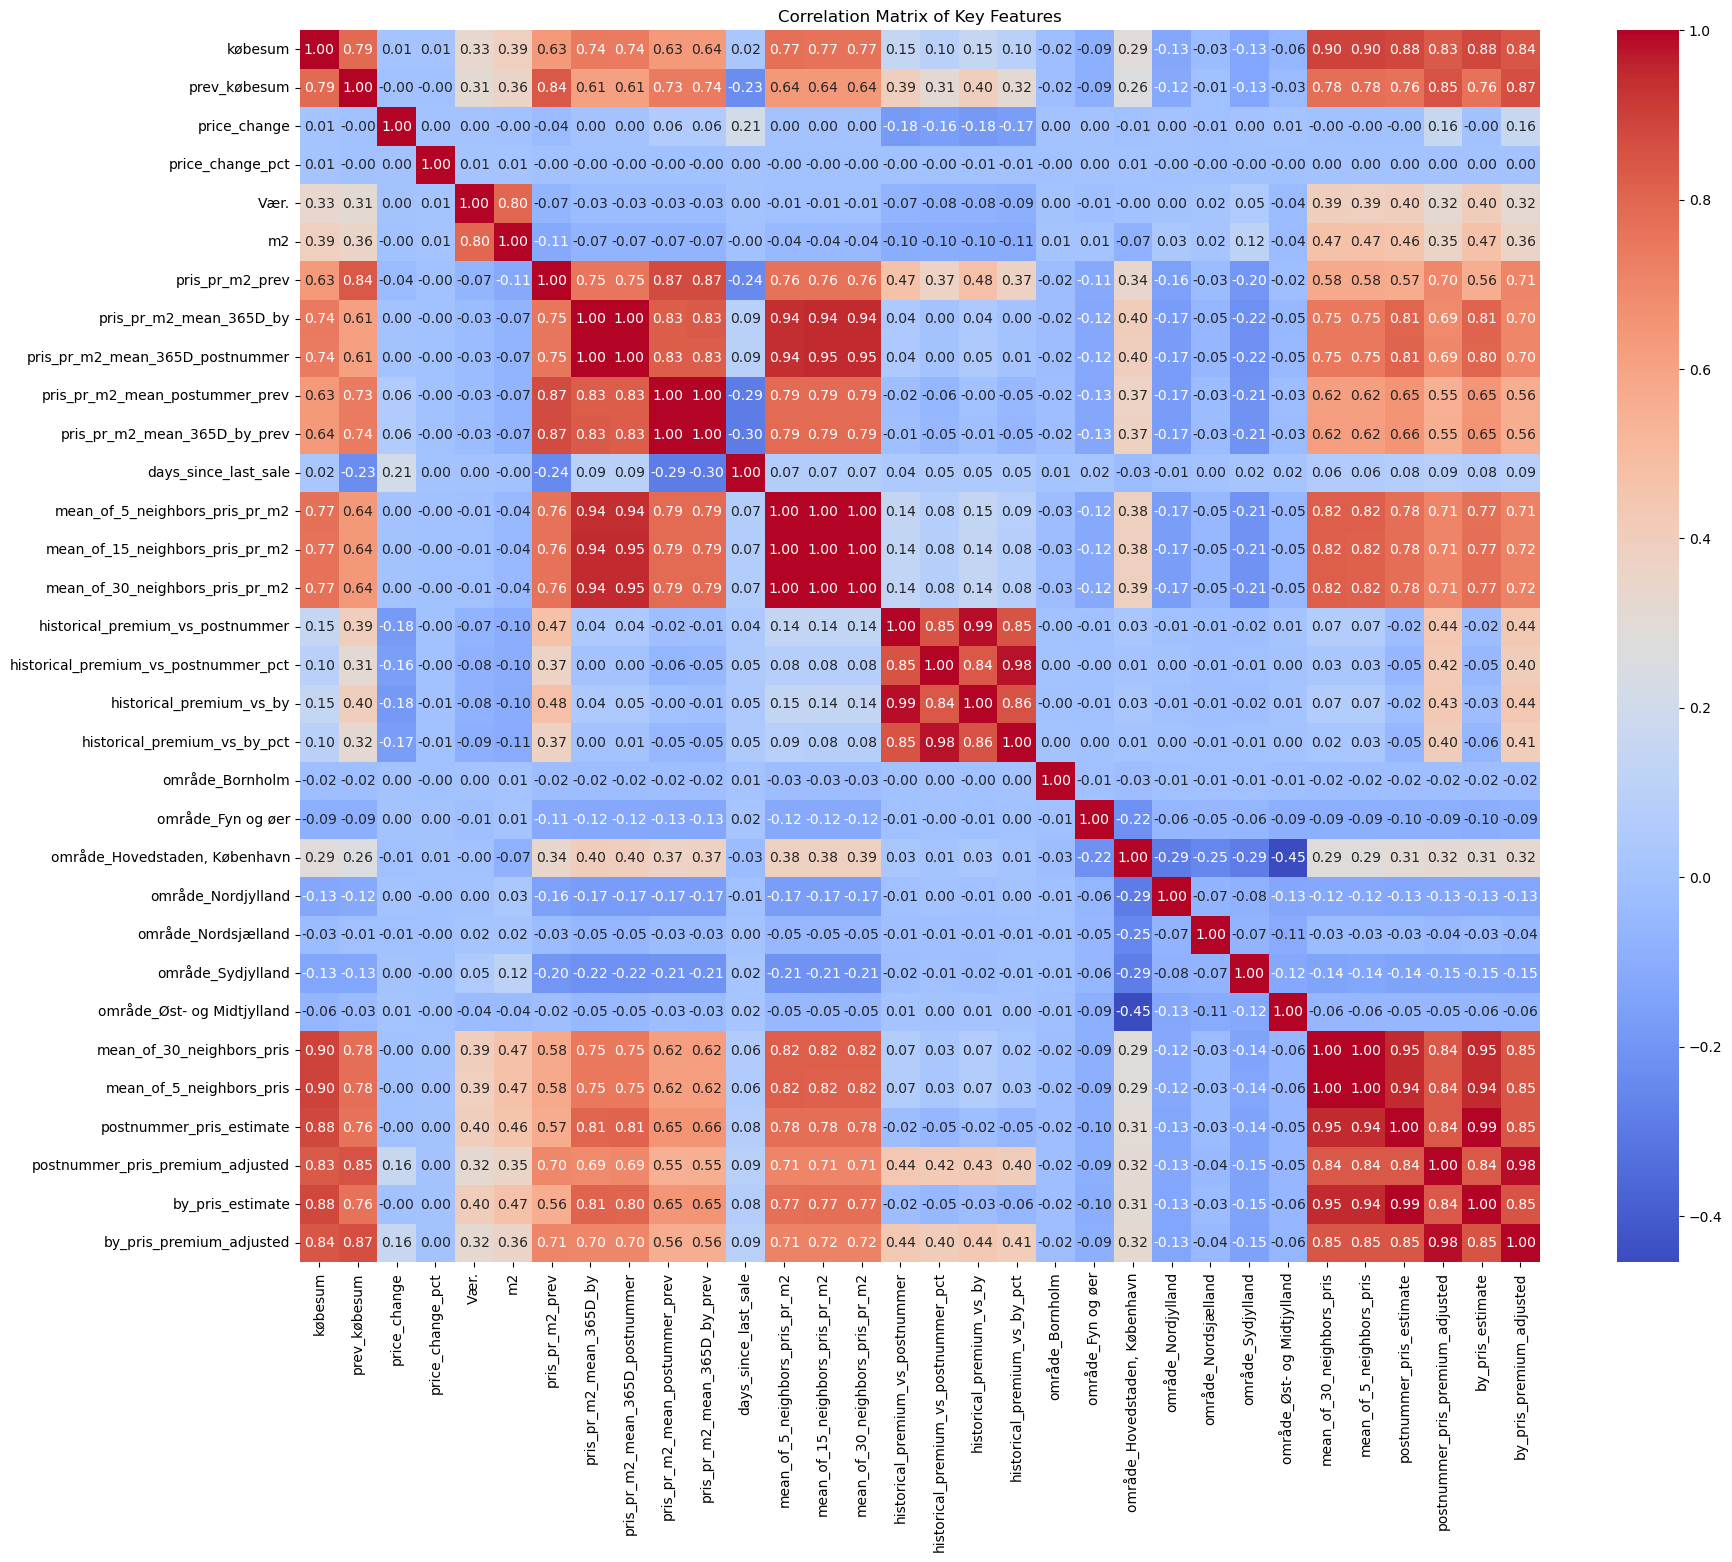

In [55]:
#putting away the bad
correlation_matrix = df.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Key Features')
plt.show()

# honestly i could remove more features but i am going to wait to see what you say

overall mape: 24.5%


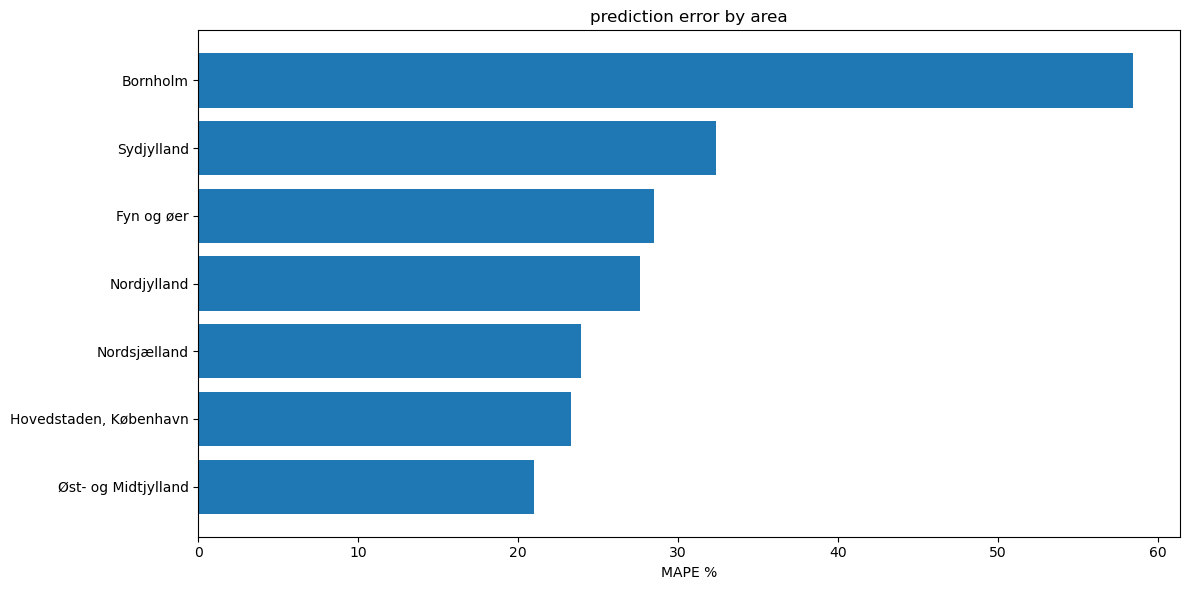

In [50]:
# just checking how good the nn times price is by area
df

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

actual = df['købesum']
pred = df['mean_of_5_neighbors_pris']

# clean up the data
clean_data = df.dropna(subset=['købesum', 'mean_of_5_neighbors_pris'])

print(f"overall mape: {mape(clean_data['købesum'], clean_data['mean_of_5_neighbors_pris']):.1f}%")

# by area
area_cols = [col for col in clean_data.columns if 'område_' in col]

# quick plot
results = []
for col in area_cols:
    area_data = clean_data[clean_data[col] == 1]
    area_name = col.replace('område_', '')
    area_mape = mape(area_data['købesum'], area_data['mean_of_5_neighbors_pris'])
    results.append([area_name, area_mape, len(area_data)])

results_df = pd.DataFrame(results, columns=['area', 'mape', 'count'])
results_df = results_df.sort_values('mape')

plt.figure(figsize=(12, 6))
plt.barh(results_df['area'], results_df['mape'])
plt.xlabel('MAPE %')
plt.title('prediction error by area')
plt.tight_layout()
plt.show()